In [1]:
# 1. Import Packages
import os
import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


In [2]:
# 2. Reproducibility and Device
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
# 3. Read Data
# If you run this notebook on Kaggle, change DATA_DIR if necessary.
DATA_DIR = "/home/longpm/works/knowledge/llm-nycu/hw1/data/problem2"

train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

# Local fallback
if not os.path.exists(train_path):
    DATA_DIR = "."
    train_path = os.path.join(DATA_DIR, "train.csv")
    val_path = os.path.join(DATA_DIR, "val.csv")
    test_path = os.path.join(DATA_DIR, "test.csv")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_df.head())
display(val_df.head())
display(test_df.head())


Train: (25531, 5)
Validation: (3647, 5)
Test: (7295, 4)


,id,anchor,target,context,score
0,808c9edf2bfa8770,gate insulator film,gate insulator thickness,H01,0.50
1,17d1d9d4da553fa5,rotary electric,controller of rotary electric machine,B64,0.50
2,9905ae6440094df0,based method,method of teaching,G01,0.00
3,66766be479f904f2,inner closed,axial,B24,0.25
4,6bcfd7479a107de8,predetermined acceleration,given speed,B66,0.25


,id,anchor,target,context,score
0,af96f2c33e268529,auxiliary water,supplementing water,F24,0.50
1,e028ad0e05f58a48,membrane vesicle,lipid membranes,A61,0.75
2,362c2f8b3decb62a,triethylammonium salt,triethylammonium acetate,C07,0.50
3,1f4cf5caea3b0e65,sensitive photographic,sensitive silver photographic,H01,0.50
4,b640037b4b1cee75,movement directions,directions,B60,0.50


,id,anchor,target,context
0,56c8cc4180a9ea16,return structure,return prevention structure,F27
1,d432a6416712e59a,pressure failure,impact,F02
2,e7ab59f580fd7184,define panel,committee,C02
3,03ab2935bce8a3eb,roll on workpiece,roll on object,B23
4,494f877d48deb27f,arcade,archery game,A63


In [4]:
# 4. Tokenizer and Input Construction

def tokenizer(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return text.strip().split()

def tokenize_input(context, anchor, target):
    # Keep the special tokens while tokenizing the remaining text.
    pieces = ["<context>"]
    pieces += tokenizer(context)
    pieces += ["<sep>"]
    pieces += tokenizer(anchor)
    pieces += ["<sep>"]
    pieces += tokenizer(target)
    return pieces


In [5]:
# 5. Build Vocabulary from TRAINING DATA ONLY

def build_vocab(df, min_freq=1):
    counter = Counter()

    for _, row in df.iterrows():
        tokens = tokenize_input(row["context"], row["anchor"], row["target"])
        counter.update(tokens)

    vocab = {
        "<pad>": 0,
        "<unk>": 1,
        "<context>": 2,
        "<sep>": 3,
    }

    for token, freq in counter.items():
        if freq >= min_freq and token not in vocab:
            vocab[token] = len(vocab)

    return vocab

vocab = build_vocab(train_df)
PAD_IDX = vocab["<pad>"]
UNK_IDX = vocab["<unk>"]

print("Vocabulary size:", len(vocab))


Vocabulary size: 7749


In [6]:
# 6. Preprocess Data

MAX_LEN = 64

def encode_example(context, anchor, target, vocab, max_len=MAX_LEN):
    tokens = tokenize_input(context, anchor, target)
    ids = [vocab.get(token, UNK_IDX) for token in tokens]

    ids = ids[:max_len]
    attention_mask = [1] * len(ids)

    pad_len = max_len - len(ids)
    ids += [PAD_IDX] * pad_len
    attention_mask += [0] * pad_len

    return torch.tensor(ids, dtype=torch.long), torch.tensor(attention_mask, dtype=torch.float)

class PatentSimilarityDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.vocab = vocab
        self.max_len = max_len
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        input_ids, attention_mask = encode_example(
            row["context"],
            row["anchor"],
            row["target"],
            self.vocab,
            self.max_len,
        )

        item = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "id": row["id"],
        }

        if self.has_labels:
            item["score"] = torch.tensor(float(row["score"]), dtype=torch.float)

        return item


In [7]:
# 7. Create DataLoaders

BATCH_SIZE = 64

train_dataset = PatentSimilarityDataset(train_df, vocab, has_labels=True)
val_dataset = PatentSimilarityDataset(val_df, vocab, has_labels=True)
test_dataset = PatentSimilarityDataset(test_df, vocab, has_labels=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("score:", batch["score"].shape)


input_ids: torch.Size([64, 64])
attention_mask: torch.Size([64, 64])
score: torch.Size([64])


In [8]:
# 8. Positional Encoding

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


In [9]:
# 9. Multi-head Attention

class MyMultiheadAttention(nn.Module):
    # ----- TODO ----- #
    # Implement Multi-head Self-Attention.
    #
    # Your implementation should include:
    # 1. Query, Key, and Value projections
    # 2. Split the projected representations into multiple attention heads
    # 3. Scaled dot-product attention
    # 4. Padding-mask handling
    # 5. Concatenation of all attention heads
    # 6. Final output projection
    #
    # Please study the Transformer paper:
    # https://arxiv.org/pdf/1706.03762
    #
    # Do NOT use torch.nn.MultiheadAttention.
    def __init__(
        self,
        *,
        d_model: int,
        nhead: int,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        if d_model % nhead != 0:
            raise ValueError(f"d_model={d_model} must be divisible by nhead={nhead}")
        self.d_model = d_model
        self.nhead = nhead
        self.d_head = d_model // nhead
        self.q_proj = nn.Linear(
            in_features=d_model,
            out_features=d_model,
        )
        self.k_proj = nn.Linear(
            in_features=d_model,
            out_features=d_model,
        )
        self.v_proj = nn.Linear(
            in_features=d_model,
            out_features=d_model,
        )
        self.out_proj = nn.Linear(
            in_features=d_model,
            out_features=d_model,
        )
        self.attn_dropout = nn.Dropout(p=dropout)

    def split_heads(self, *, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, _ = x.shape
        return x.view(batch_size, seq_len, self.nhead, self.d_head).transpose(1, 2)

    def merge_heads(self, *, x: torch.Tensor) -> torch.Tensor:
        batch_size, _, seq_len, _ = x.shape
        return x.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        q = self.split_heads(x=self.q_proj(x))
        k = self.split_heads(x=self.k_proj(x))
        v = self.split_heads(x=self.v_proj(x))
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores = scores.masked_fill(attention_mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_dropout(
            torch.softmax(
                scores,
                dim=-1,
            )
        )
        return self.out_proj(self.merge_heads(x=torch.matmul(weights, v)))
    # ----- TODO ----- #


In [10]:
# 10. Transformer Encoder Layer

class MyTransformerEncoderLayer(nn.Module):
    # ----- TODO ----- #
    # Implement one Transformer Encoder Layer.
    #
    # Your implementation should include:
    # 1. Multi-head self-attention using MyMultiheadAttention
    # 2. Residual connection after self-attention
    # 3. Layer normalization
    # 4. Position-wise feed-forward network
    # 5. Residual connection after the feed-forward network
    # 6. Layer normalization
    # 7. Dropout
    #
    # Please study the Transformer paper:
    # https://arxiv.org/pdf/1706.03762
    def __init__(
        self,
        *,
        d_model: int,
        nhead: int,
        dim_feedforward: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.self_attn = MyMultiheadAttention(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
        )
        self.feed_forward = nn.Sequential(
            nn.Linear(
                in_features=d_model,
                out_features=dim_feedforward,
            ),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(
                in_features=dim_feedforward,
                out_features=d_model,
            ),
        )
        self.norm1 = nn.LayerNorm(normalized_shape=d_model)
        self.norm2 = nn.LayerNorm(normalized_shape=d_model)
        self.dropout1 = nn.Dropout(p=dropout)
        self.dropout2 = nn.Dropout(p=dropout)

    def forward(
        self,
        x: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        x = self.norm1(x + self.dropout1(self.self_attn(x, attention_mask)))
        return self.norm2(x + self.dropout2(self.feed_forward(x)))
    # ----- TODO ----- #


In [11]:
# 11. Transformer Regressor

class TransformerRegressor(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        pad_idx,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.2,
        max_len=MAX_LEN,
    ):
        super().__init__()

        self.pad_idx = pad_idx
        self.d_model = embedding_dim

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=pad_idx
        )

        self.pos_encoder = PositionalEncoding(
            d_model=embedding_dim,
            max_len=max_len
        )

        self.dropout = nn.Dropout(dropout)

        self.encoder_layers = nn.ModuleList([
            MyTransformerEncoderLayer(
                d_model=embedding_dim,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])

        self.regression_head = nn.Linear(embedding_dim, 1)

    def masked_mean_pooling(self, x, attention_mask):
        mask = attention_mask.unsqueeze(-1)
        x = x * mask
        summed = x.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.dropout(x)

        for layer in self.encoder_layers:
            x = layer(x, attention_mask)

        # ----- TODO (Optional) ----- #
        # Modify the pooling strategy to improve model performance.
        # The default setting uses masked mean pooling.
        pooled = self.masked_mean_pooling(x, attention_mask)
        # ----- TODO (Optional) ----- #
        
        logits = self.regression_head(pooled).squeeze(-1)

        # Constrain predictions to (0, 1)
        return torch.sigmoid(logits)


In [12]:
# 12. Define Hyperparameters

# Fixed settings
EMBEDDING_DIM = 128
NUM_LAYERS = 2

# ----- TODO ----- #
# Use NHEAD = 4 for the main experiment.
# Then compare NHEAD = 1, 4, and 8 using the same data split
# and training budget.
NHEAD = 4
# ----- TODO ----- #

# ----- TODO (Optional) ----- #
# Tune these hyperparameters to improve validation
# Pearson correlation. Document every modification you make.
DIM_FEEDFORWARD = 512
DROPOUT = 0.05
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 0.01
MIN_LEARNING_RATE = 1e-5
EPOCHS = 20
# ----- TODO (Optional) ----- #

assert EMBEDDING_DIM % NHEAD == 0

model = TransformerRegressor(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    pad_idx=PAD_IDX,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=MAX_LEN,
).to(device)

print(model)


TransformerRegressor(
  (embedding): Embedding(7749, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (dropout): Dropout(p=0.05, inplace=False)
  (encoder_layers): ModuleList(
    (0-1): 2 x MyTransformerEncoderLayer(
      (self_attn): MyMultiheadAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (attn_dropout): Dropout(p=0.05, inplace=False)
      )
      (feed_forward): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.05, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
     

In [13]:
# 13. Evaluation Metrics

def pearson_corr(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0

    return float(np.corrcoef(y_true, y_pred)[0, 1])

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


In [14]:
# 14. Define Loss Function and Optimizer

criterion = nn.MSELoss()

# ----- TODO ----- #
# Choose an optimizer and set its hyperparameters.
# You may consider Adam, AdamW, SGD, etc.
def reset_embedding(*, model: TransformerRegressor) -> None:
    nn.init.normal_(
        tensor=model.embedding.weight,
        mean=0.0,
        std=model.d_model**-0.5,
    )
    with torch.no_grad():
        model.embedding.weight[model.pad_idx].zero_()


def build_optimizer(
    *,
    model: nn.Module,
    lr: float,
    weight_decay: float,
) -> optim.Optimizer:
    return optim.AdamW(
        params=[
            {
                "params": [parameter for parameter in model.parameters() if parameter.dim() > 1],
                "weight_decay": weight_decay,
            },
            {
                "params": [parameter for parameter in model.parameters() if parameter.dim() <= 1],
                "weight_decay": 0.0,
            },
        ],
        lr=lr,
    )


reset_embedding(model=model)
optimizer = build_optimizer(
    model=model,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
# ----- TODO ----- #

# ----- TODO (Optional) ----- #
# Use a learning-rate scheduler to improve performance.
def build_scheduler(
    *,
    optimizer: optim.Optimizer,
    epochs: int,
) -> optim.lr_scheduler.LRScheduler:
    return optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer,
        T_max=epochs,
        eta_min=MIN_LEARNING_RATE,
    )


scheduler = build_scheduler(
    optimizer=optimizer,
    epochs=EPOCHS,
)
# ----- TODO (Optional) ----- #

In [15]:
# 15. Training and Validation Functions

def evaluate_model(model, data_loader, criterion):
    model.eval()

    losses = []
    all_scores = []
    all_predictions = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            scores = batch["score"].to(device)

            predictions = model(input_ids, attention_mask)
            loss = criterion(predictions, scores)

            losses.append(loss.item())
            all_scores.extend(scores.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    val_loss = float(np.mean(losses))
    val_pearson = pearson_corr(all_scores, all_predictions)
    val_rmse = rmse(all_scores, all_predictions)

    return val_loss, val_pearson, val_rmse


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, scheduler=None):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_pearson": [],
        "val_rmse": [],
    }

    best_pearson = -float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            scores = batch["score"].to(device)

            optimizer.zero_grad()

            predictions = model(input_ids, attention_mask)
            loss = criterion(predictions, scores)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_loss, val_pearson, val_rmse_value = evaluate_model(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_pearson"].append(val_pearson)
        history["val_rmse"].append(val_rmse_value)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_pearson > best_pearson:
            best_pearson = val_pearson
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Pearson: {val_pearson:.4f} | "
            f"Val RMSE: {val_rmse_value:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [16]:
# 16. Train Model

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    scheduler=scheduler,
)


Epoch 01/20 | Train Loss: 0.0669 | Val Loss: 0.0640 | Val Pearson: 0.2999 | Val RMSE: 0.2530


Epoch 02/20 | Train Loss: 0.0536 | Val Loss: 0.0578 | Val Pearson: 0.3667 | Val RMSE: 0.2405


Epoch 03/20 | Train Loss: 0.0470 | Val Loss: 0.0595 | Val Pearson: 0.3810 | Val RMSE: 0.2440


Epoch 04/20 | Train Loss: 0.0438 | Val Loss: 0.0582 | Val Pearson: 0.3950 | Val RMSE: 0.2413


Epoch 05/20 | Train Loss: 0.0404 | Val Loss: 0.0593 | Val Pearson: 0.3950 | Val RMSE: 0.2434


...

Epoch 16/20 | Train Loss: 0.0227 | Val Loss: 0.0603 | Val Pearson: 0.4473 | Val RMSE: 0.2456


Epoch 17/20 | Train Loss: 0.0217 | Val Loss: 0.0600 | Val Pearson: 0.4484 | Val RMSE: 0.2450


Epoch 18/20 | Train Loss: 0.0211 | Val Loss: 0.0603 | Val Pearson: 0.4477 | Val RMSE: 0.2456


Epoch 19/20 | Train Loss: 0.0206 | Val Loss: 0.0610 | Val Pearson: 0.4499 | Val RMSE: 0.2469


Epoch 20/20 | Train Loss: 0.0204 | Val Loss: 0.0607 | Val Pearson: 0.4497 | Val RMSE: 0.2463


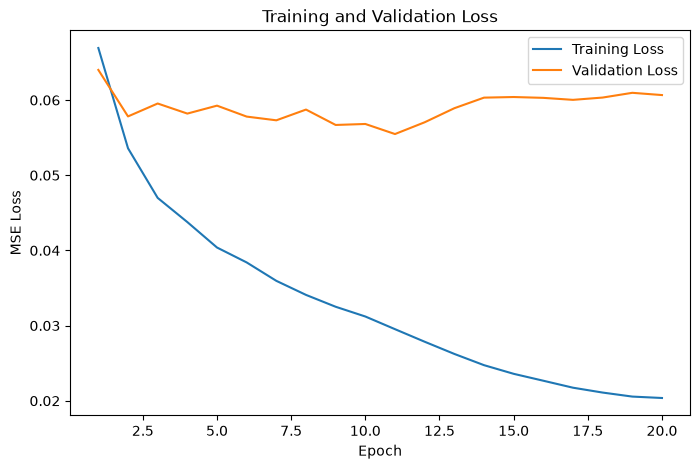

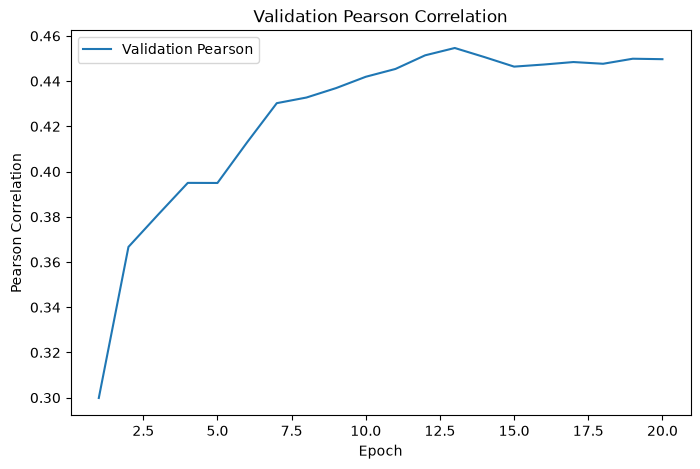

In [17]:
# 17. Plot Learning Curves

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Training Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["val_pearson"], label="Validation Pearson")
plt.xlabel("Epoch")
plt.ylabel("Pearson Correlation")
plt.title("Validation Pearson Correlation")
plt.legend()
plt.show()


**Discussion for (a)**

The main model uses 4 attention heads and keeps the default masked mean pooling. The training loss falls steadily from 0.067 in the first epoch to 0.020 in the last one, while the validation loss reaches its lowest value of 0.056 at epoch 11 and then drifts up to about 0.061. The validation Pearson correlation keeps improving for longer, from 0.300 after the first epoch to its best value of 0.455 at epoch 13, and that checkpoint is the one that is kept. The widening gap between the two loss curves shows that the model starts to memorise the training pairs after a few epochs, which is why the checkpoint is chosen with the validation Pearson correlation instead of taking the last epoch.

In [18]:
# 18. Final Validation Evaluation

val_loss, val_pearson, val_rmse_value = evaluate_model(
    model, val_loader, criterion
)

print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Pearson : {val_pearson:.4f}")
print(f"Validation RMSE    : {val_rmse_value:.4f}")


Validation Loss    : 0.0589
Validation Pearson : 0.4547
Validation RMSE    : 0.2427


**Discussion for (b)**

On the validation set the main 4-head model reaches a Pearson correlation of 0.4547 and an RMSE of 0.2427. The standard deviation of the validation scores is 0.258, so always predicting the mean score would give an RMSE of about 0.258, and the model is clearly better than that baseline but still far from perfect. I think the main limitation is the pooling. Mean pooling averages the context, the anchor and the target into one vector, so the head never sees a direct comparison between the two phrases. The ensemble in section 21 adds that comparison and reaches 0.7251 with an RMSE of 0.1779.

In [19]:
# 19. Generate Submission

model.eval()

test_predictions = []
test_ids = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        predictions = model(input_ids, attention_mask)

        test_predictions.extend(predictions.cpu().numpy().tolist())
        test_ids.extend(list(batch["id"]))

# Create submission DataFrame
submission = pd.DataFrame({
    "id": test_ids,
    "score": test_predictions
})

# Check that IDs match the original test data
assert len(submission) == len(test_df)
assert submission["id"].tolist() == test_df["id"].tolist()

# Save submission file
submission.to_csv("submission.csv", index=False)

print("submission.csv has been generated successfully.")
print(submission.head())

submission.csv has been generated successfully.
                 id     score
0  56c8cc4180a9ea16  0.391981
1  d432a6416712e59a  0.670580
2  e7ab59f580fd7184  0.231842
3  03ab2935bce8a3eb  0.618910
4  494f877d48deb27f  0.055191


===== NHEAD = 1 =====


Epoch 01/20 | Train Loss: 0.0695 | Val Loss: 0.0666 | Val Pearson: 0.1610 | Val RMSE: 0.2582


Epoch 02/20 | Train Loss: 0.0595 | Val Loss: 0.0596 | Val Pearson: 0.3368 | Val RMSE: 0.2442


Epoch 03/20 | Train Loss: 0.0495 | Val Loss: 0.0582 | Val Pearson: 0.3724 | Val RMSE: 0.2412


Epoch 04/20 | Train Loss: 0.0442 | Val Loss: 0.0582 | Val Pearson: 0.3984 | Val RMSE: 0.2413


...

Epoch 17/20 | Train Loss: 0.0141 | Val Loss: 0.0574 | Val Pearson: 0.4965 | Val RMSE: 0.2396


Epoch 18/20 | Train Loss: 0.0134 | Val Loss: 0.0575 | Val Pearson: 0.4976 | Val RMSE: 0.2399


Epoch 19/20 | Train Loss: 0.0130 | Val Loss: 0.0576 | Val Pearson: 0.4968 | Val RMSE: 0.2400


Epoch 20/20 | Train Loss: 0.0129 | Val Loss: 0.0578 | Val Pearson: 0.4969 | Val RMSE: 0.2405


,d_head,val_pearson,val_rmse,best_epoch
nhead,,,,
1,128,0.467004,0.239475,20
4,32,0.454654,0.242738,13
8,16,0.498324,0.239148,16


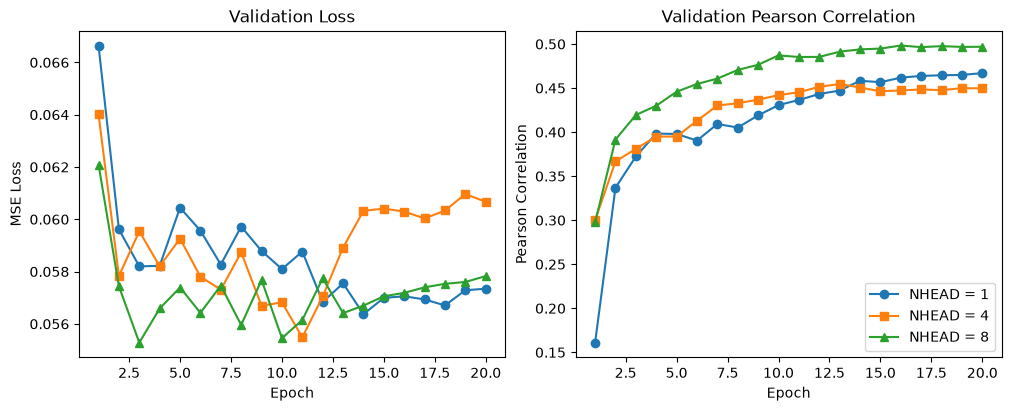

In [20]:
# 20. Effect of the Number of Attention Heads
HEAD_COUNTS = (1, 4, 8)


def train_head_variant(*, nhead: int) -> tuple[TransformerRegressor, dict[str, list[float]]]:
    torch.manual_seed(SEED)
    variant = TransformerRegressor(
        vocab_size=len(vocab),
        embedding_dim=EMBEDDING_DIM,
        pad_idx=PAD_IDX,
        nhead=nhead,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        dropout=DROPOUT,
        max_len=MAX_LEN,
    ).to(device)
    reset_embedding(model=variant)
    variant_optimizer = build_optimizer(
        model=variant,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    variant_history = train_model(
        model=variant,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=variant_optimizer,
        epochs=EPOCHS,
        scheduler=build_scheduler(
            optimizer=variant_optimizer,
            epochs=EPOCHS,
        ),
    )
    return variant, variant_history


head_models, head_histories = {NHEAD: model}, {NHEAD: history}
for nhead in HEAD_COUNTS:
    if nhead not in head_models:
        print(f"===== NHEAD = {nhead} =====")
        head_models[nhead], head_histories[nhead] = train_head_variant(nhead=nhead)

head_rows = []
for nhead in HEAD_COUNTS:
    _, head_pearson, head_rmse = evaluate_model(head_models[nhead], val_loader, criterion)
    head_rows.append(
        {
            "nhead": nhead,
            "d_head": EMBEDDING_DIM // nhead,
            "val_pearson": head_pearson,
            "val_rmse": head_rmse,
            "best_epoch": int(np.argmax(head_histories[nhead]["val_pearson"])) + 1,
        }
    )
display(pd.DataFrame(data=head_rows).set_index(keys="nhead"))

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 4),
    constrained_layout=True,
)
for nhead, marker in zip(HEAD_COUNTS, ("o", "s", "^")):
    epochs_range = range(1, len(head_histories[nhead]["val_pearson"]) + 1)
    axes[0].plot(
        epochs_range,
        head_histories[nhead]["val_loss"],
        marker=marker,
        label=f"NHEAD = {nhead}",
    )
    axes[1].plot(
        epochs_range,
        head_histories[nhead]["val_pearson"],
        marker=marker,
        label=f"NHEAD = {nhead}",
    )
axes[0].set(
    title="Validation Loss",
    xlabel="Epoch",
    ylabel="MSE Loss",
)
axes[1].set(
    title="Validation Pearson Correlation",
    xlabel="Epoch",
    ylabel="Pearson Correlation",
)
axes[1].legend()
plt.show()

**Discussion for (c)**

The three settings use the same data split, seed, number of epochs, optimizer and pooling, and only the number of heads changes. Since d_model is fixed to 128, the number of parameters is identical and only the size of each head changes.

| Heads | Head size | Val Pearson | Val RMSE | Best epoch |
|---|---|---|---|---|
| 1 | 128 | 0.4670 | 0.2395 | 20 |
| 4 | 32 | 0.4547 | 0.2427 | 13 |
| 8 | 16 | 0.4983 | 0.2391 | 16 |

Eight heads give the best result, about 0.03 to 0.04 above one and four heads, and the 8-head model also fits the training data faster (final training loss 0.013 against 0.020 for four heads and 0.025 for one head). With mean pooling the only place where anchor and target tokens can interact is the attention itself, so splitting it into several small heads lets the model look at the pair in several ways at once. The order between one and four heads is not stable, though. In an earlier run of the same notebook four heads scored 0.463 and one head 0.423, so differences of this size are partly run-to-run noise on the GPU. The inputs are also very short (8.4 tokens on average and at most 18), so heads of 16 dimensions are still enough to represent them.

In [21]:
# 21. Ensemble Method
import difflib
from collections import defaultdict
from dataclasses import dataclass, replace

SEP_IDX = vocab["<sep>"]
SCORE_LEVELS = (0.0, 0.25, 0.5, 0.75, 1.0)
POOLING_MULTIPLIER = {"segment": 5, "segment_max": 7, "align": 9, "align_max": 11}
ALIGN_SCALARS = 2
MASK_FILL = -1e4
ALIGNMENT_BLOCKS = 2
FUSION_INPUTS = 4
PYRAMID_CHANNELS = 3
PYRAMID_HIDDEN = 16
PYRAMID_OUTPUT = 32
PYRAMID_KERNEL = 3
PYRAMID_GRID = 4
SOFTMAX_LEARNING_RATE = 1e-3
SOFTMAX_WEIGHT_DECAY = 0.05
USE_LEXICAL_FEATURES = True
USE_NEIGHBOUR_FEATURES = True
NEIGHBOUR_TEMPERATURE = 8.0
ENSEMBLE_SEEDS = (42, 43)
ENSEMBLE_SUBMISSION_PATH = "submission_ensemble.csv"
LEXICAL_FEATURE_NAMES = (
    "stem_overlap",
    "char_trigram_jaccard",
    "edit_ratio",
    "char_bigram_jaccard",
    "char_fourgram_jaccard",
    "short_stem_overlap",
    "long_stem_overlap",
    "soft_match_anchor",
    "soft_match_target",
    "soft_match_min",
)
NEIGHBOUR_FEATURE_NAMES = (
    "anchor_mean_score",
    "similarity_weighted_score",
    "nearest_target_score",
    "nearest_target_similarity",
)
FEATURE_NAMES = LEXICAL_FEATURE_NAMES + (NEIGHBOUR_FEATURE_NAMES if USE_NEIGHBOUR_FEATURES else ())


def jaccard(
    *,
    left: set[str],
    right: set[str],
) -> float:
    return len(left & right) / max(1, len(left | right))


def char_grams(
    *,
    text: str,
    size: int = 3,
) -> set[str]:
    padded = f" {text} "
    return {padded[i : i + size] for i in range(len(padded) - size + 1)}


def stems(
    *,
    words: list[str],
    length: int,
) -> set[str]:
    return {word[:length] for word in words}


def best_word_matches(
    *,
    source: list[str],
    other: list[str],
) -> list[float]:
    return [
        max(
            [
                jaccard(
                    left=char_grams(text=word),
                    right=char_grams(text=candidate),
                )
                for candidate in other
            ]
            or [0.0]
        )
        for word in source
    ]


def lexical_features(
    *,
    anchor: str,
    target: str,
) -> list[float]:
    anchor_words, target_words = tokenizer(anchor), tokenizer(target)
    anchor_text, target_text = " ".join(anchor_words), " ".join(target_words)
    anchor_matches = best_word_matches(
        source=anchor_words,
        other=target_words,
    )
    target_matches = best_word_matches(
        source=target_words,
        other=anchor_words,
    )
    return [
        jaccard(
            left=stems(
                words=anchor_words,
                length=4,
            ),
            right=stems(
                words=target_words,
                length=4,
            ),
        ),
        jaccard(
            left=char_grams(text=anchor_text),
            right=char_grams(text=target_text),
        ),
        difflib.SequenceMatcher(None, anchor_text, target_text).ratio(),
        jaccard(
            left=char_grams(
                text=anchor_text,
                size=2,
            ),
            right=char_grams(
                text=target_text,
                size=2,
            ),
        ),
        jaccard(
            left=char_grams(
                text=anchor_text,
                size=4,
            ),
            right=char_grams(
                text=target_text,
                size=4,
            ),
        ),
        jaccard(
            left=stems(
                words=anchor_words,
                length=3,
            ),
            right=stems(
                words=target_words,
                length=3,
            ),
        ),
        jaccard(
            left=stems(
                words=anchor_words,
                length=5,
            ),
            right=stems(
                words=target_words,
                length=5,
            ),
        ),
        float(np.mean(anchor_matches)) if anchor_matches else 0.0,
        float(np.mean(target_matches)) if target_matches else 0.0,
        min(anchor_matches + target_matches) if anchor_matches and target_matches else 0.0,
    ]


train_mean_score = float(train_df["score"].mean())
train_by_anchor = defaultdict(list)
for position, row in enumerate(train_df.itertuples(index=False)):
    train_by_anchor[row.anchor].append((position, char_grams(text=" ".join(tokenizer(row.target))), row.score))


def neighbour_features(
    *,
    anchor: str,
    target: str,
    position: int | None,
) -> list[float]:
    target_grams = char_grams(text=" ".join(tokenizer(target)))
    neighbours = [(grams, score) for index, grams, score in train_by_anchor.get(anchor, []) if index != position]
    if not neighbours:
        return [train_mean_score, train_mean_score, 0.0, 0.0]
    similarities = np.array(
        [
            jaccard(
                left=target_grams,
                right=grams,
            )
            for grams, _ in neighbours
        ]
    )
    scores = np.array([score for _, score in neighbours])
    weights = np.exp(NEIGHBOUR_TEMPERATURE * similarities)
    nearest = int(similarities.argmax())
    return [
        float(scores.mean()),
        float((weights * scores).sum() / weights.sum()),
        float(scores[nearest]),
        float(similarities[nearest]),
    ]


def row_features(
    *,
    anchor: str,
    target: str,
    position: int | None,
) -> list[float]:
    features = lexical_features(
        anchor=anchor,
        target=target,
    )
    if USE_NEIGHBOUR_FEATURES:
        features += neighbour_features(
            anchor=anchor,
            target=target,
            position=position,
        )
    return features


class LexicalDataset(Dataset):
    def __init__(
        self,
        *,
        base: PatentSimilarityDataset,
        exclude_self: bool,
    ) -> None:
        self.items = [base[index] for index in range(len(base))]
        self.lexical = torch.tensor(
            [
                row_features(
                    anchor=row.anchor,
                    target=row.target,
                    position=index if exclude_self else None,
                )
                for index, row in enumerate(base.df.itertuples(index=False))
            ],
            dtype=torch.float,
        )

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> dict:
        return {**self.items[idx], "lexical": self.lexical[idx]}


@dataclass(
    frozen=True,
    slots=True,
)
class EnsembleMember:
    nhead: int
    pooling: str
    head: str = "sigmoid"
    learning_rate: float = LEARNING_RATE
    weight_decay: float = WEIGHT_DECAY
    seed: int = SEED

    @property
    def name(self) -> str:
        return (
            f"nhead={self.nhead}, pooling={self.pooling}, head={self.head}, lr={self.learning_rate}, seed={self.seed}"
        )


# RE2 alignment fusion (refine): Yang et al., Simple and Effective Text Matching with Richer Alignment Features,
# ACL 2019, https://arxiv.org/abs/1908.00300
# MatchPyramid interaction matrix (interaction, pyramid): Pang et al., Text Matching as Image Recognition,
# AAAI 2016, https://arxiv.org/abs/1602.06359
class EnsembleRegressor(TransformerRegressor):
    def __init__(
        self,
        *,
        member: EnsembleMember,
        lexical_features: int,
    ) -> None:
        super().__init__(
            vocab_size=len(vocab),
            embedding_dim=EMBEDDING_DIM,
            pad_idx=PAD_IDX,
            nhead=member.nhead,
            num_layers=NUM_LAYERS,
            dim_feedforward=DIM_FEEDFORWARD,
            dropout=DROPOUT,
            max_len=MAX_LEN,
        )
        self.member = member
        in_features = (
            EMBEDDING_DIM * POOLING_MULTIPLIER[member.pooling]
            + (ALIGN_SCALARS if member.pooling.startswith("align") else 0)
            + lexical_features
            + PYRAMID_OUTPUT * PYRAMID_GRID * PYRAMID_GRID
        )
        self.regression_head = nn.Linear(
            in_features=in_features,
            out_features=len(SCORE_LEVELS) if member.head == "softmax" else 1,
        )
        self.fusions = nn.ModuleList(
            [
                nn.Linear(
                    in_features=FUSION_INPUTS * EMBEDDING_DIM,
                    out_features=EMBEDDING_DIM,
                )
                for _ in range(ALIGNMENT_BLOCKS)
            ]
        )
        self.fusion_norms = nn.ModuleList(
            [nn.LayerNorm(normalized_shape=EMBEDDING_DIM) for _ in range(ALIGNMENT_BLOCKS)]
        )
        self.pyramid = nn.Sequential(
            nn.Conv2d(
                in_channels=PYRAMID_CHANNELS,
                out_channels=PYRAMID_HIDDEN,
                kernel_size=PYRAMID_KERNEL,
                padding=PYRAMID_KERNEL // 2,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=PYRAMID_HIDDEN,
                out_channels=PYRAMID_OUTPUT,
                kernel_size=PYRAMID_KERNEL,
                padding=PYRAMID_KERNEL // 2,
            ),
            nn.ReLU(),
            nn.AdaptiveMaxPool2d(output_size=(PYRAMID_GRID, PYRAMID_GRID)),
            nn.Flatten(),
        )
        self.register_buffer(
            name="score_levels",
            tensor=torch.tensor(SCORE_LEVELS),
        )
        reset_embedding(model=self)

    def masked_max(
        self,
        *,
        x: torch.Tensor,
        mask: torch.Tensor,
    ) -> torch.Tensor:
        return x.masked_fill(mask.unsqueeze(-1) == 0, MASK_FILL).max(dim=1).values

    def segment_masks(
        self,
        *,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        is_sep = input_ids == SEP_IDX
        segment_id = torch.cumsum(
            is_sep.long(),
            dim=1,
        )
        valid = attention_mask * (~is_sep).float()
        return valid * (segment_id == 1).float(), valid * (segment_id == 2).float()

    def align_features(
        self,
        *,
        x: torch.Tensor,
        anchor_mask: torch.Tensor,
        target_mask: torch.Tensor,
    ) -> torch.Tensor:
        scores = torch.matmul(x, x.transpose(1, 2)) / math.sqrt(x.size(-1))
        to_target = (
            torch.softmax(
                scores.masked_fill(target_mask[:, None, :] == 0, MASK_FILL),
                dim=-1,
            )
            @ x
        )
        to_anchor = (
            torch.softmax(
                scores.masked_fill(anchor_mask[:, None, :] == 0, MASK_FILL),
                dim=-1,
            )
            @ x
        )
        normalized = F.normalize(
            x,
            dim=-1,
        )
        cosine = torch.matmul(normalized, normalized.transpose(1, 2))
        anchor_best = cosine.masked_fill(target_mask[:, None, :] == 0, -1.0).max(dim=-1).values
        target_best = cosine.masked_fill(anchor_mask[:, None, :] == 0, -1.0).max(dim=-1).values
        return torch.cat(
            [
                self.masked_mean_pooling((x - to_target).abs(), anchor_mask),
                self.masked_mean_pooling(x * to_target, anchor_mask),
                self.masked_mean_pooling((x - to_anchor).abs(), target_mask),
                self.masked_mean_pooling(x * to_anchor, target_mask),
                (anchor_best * anchor_mask).sum(
                    1,
                    keepdim=True,
                )
                / anchor_mask.sum(
                    1,
                    keepdim=True,
                ).clamp(min=1),
                (target_best * target_mask).sum(
                    1,
                    keepdim=True,
                )
                / target_mask.sum(
                    1,
                    keepdim=True,
                ).clamp(min=1),
            ],
            dim=-1,
        )

    def segment_pooling(
        self,
        *,
        x: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        anchor_mask, target_mask = self.segment_masks(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        h_anchor = self.masked_mean_pooling(x, anchor_mask)
        h_target = self.masked_mean_pooling(x, target_mask)
        features = [
            self.masked_mean_pooling(x, attention_mask),
            h_anchor,
            h_target,
            (h_anchor - h_target).abs(),
            h_anchor * h_target,
        ]
        if self.member.pooling.startswith("align"):
            features.append(
                self.align_features(
                    x=x,
                    anchor_mask=anchor_mask,
                    target_mask=target_mask,
                )
            )
        if self.member.pooling.endswith("max"):
            features += [
                self.masked_max(
                    x=x,
                    mask=anchor_mask,
                ),
                self.masked_max(
                    x=x,
                    mask=target_mask,
                ),
            ]
        return torch.cat(
            features,
            dim=-1,
        )

    def align_tokens(
        self,
        *,
        x: torch.Tensor,
        anchor_mask: torch.Tensor,
        target_mask: torch.Tensor,
    ) -> torch.Tensor:
        scores = torch.matmul(x, x.transpose(1, 2)) / math.sqrt(x.size(-1))
        to_target = (
            torch.softmax(
                scores.masked_fill(target_mask[:, None, :] == 0, MASK_FILL),
                dim=-1,
            )
            @ x
        )
        to_anchor = (
            torch.softmax(
                scores.masked_fill(anchor_mask[:, None, :] == 0, MASK_FILL),
                dim=-1,
            )
            @ x
        )
        other = (1.0 - anchor_mask - target_mask).clamp(min=0.0)
        return anchor_mask[..., None] * to_target + target_mask[..., None] * to_anchor + other[..., None] * x

    def refine(
        self,
        *,
        x: torch.Tensor,
        anchor_mask: torch.Tensor,
        target_mask: torch.Tensor,
    ) -> torch.Tensor:
        for fusion, norm in zip(self.fusions, self.fusion_norms):
            aligned = self.align_tokens(
                x=x,
                anchor_mask=anchor_mask,
                target_mask=target_mask,
            )
            fused = torch.relu(
                fusion(
                    torch.cat(
                        [x, aligned, x - aligned, x * aligned],
                        dim=-1,
                    )
                )
            )
            x = norm(x + self.dropout(fused))
        return x

    @staticmethod
    def interaction(
        *,
        x: torch.Tensor,
        embedded: torch.Tensor,
        input_ids: torch.Tensor,
        anchor_mask: torch.Tensor,
        target_mask: torch.Tensor,
    ) -> torch.Tensor:
        encoded = F.normalize(
            x,
            dim=-1,
        )
        embeddings = F.normalize(
            embedded,
            dim=-1,
        )
        channels = [
            torch.matmul(encoded, encoded.transpose(1, 2)),
            torch.matmul(embeddings, embeddings.transpose(1, 2)),
            (input_ids[:, :, None] == input_ids[:, None, :]).float(),
        ]
        pair_mask = anchor_mask[:, :, None] * target_mask[:, None, :]
        return (
            torch.stack(
                channels,
                dim=1,
            )
            * pair_mask[:, None]
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        lexical: torch.Tensor | None = None,
    ) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        x = self.dropout(self.pos_encoder(embedded * math.sqrt(self.d_model)))
        for layer in self.encoder_layers:
            x = layer(x, attention_mask)
        anchor_mask, target_mask = self.segment_masks(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        x = self.refine(
            x=x,
            anchor_mask=anchor_mask,
            target_mask=target_mask,
        )
        matrix = self.interaction(
            x=x,
            embedded=embedded,
            input_ids=input_ids,
            anchor_mask=anchor_mask,
            target_mask=target_mask,
        )
        pooled = torch.cat(
            [
                self.segment_pooling(
                    x=x,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                ),
                self.pyramid(matrix),
            ],
            dim=-1,
        )
        if lexical is not None:
            pooled = torch.cat(
                [pooled, lexical],
                dim=-1,
            )
        if self.member.head == "softmax":
            return (
                torch.softmax(
                    self.regression_head(pooled),
                    dim=-1,
                )
                @ self.score_levels
            )
        return torch.sigmoid(self.regression_head(pooled).squeeze(-1))


def set_seed(*, seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def lexical_input(*, batch: dict) -> torch.Tensor | None:
    return batch["lexical"].to(device) if USE_LEXICAL_FEATURES else None


@torch.no_grad()
def predict(
    *,
    model: EnsembleRegressor,
    data_loader: DataLoader,
) -> np.ndarray:
    model.eval()
    return np.concatenate(
        [
            model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                lexical_input(batch=batch),
            )
            .cpu()
            .numpy()
            for batch in data_loader
        ]
    )


def train_member(
    *,
    member: EnsembleMember,
    train_loader: DataLoader,
    val_loader: DataLoader,
) -> tuple[EnsembleRegressor, list[float]]:
    set_seed(seed=member.seed)
    member_model = EnsembleRegressor(
        member=member,
        lexical_features=len(FEATURE_NAMES) if USE_LEXICAL_FEATURES else 0,
    ).to(device)
    member_optimizer = build_optimizer(
        model=member_model,
        lr=member.learning_rate,
        weight_decay=member.weight_decay,
    )
    member_scheduler = build_scheduler(
        optimizer=member_optimizer,
        epochs=EPOCHS,
    )
    val_curve, best_state = [], None
    for epoch in range(EPOCHS):
        member_model.train()
        for batch in train_loader:
            member_optimizer.zero_grad()
            predictions = member_model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                lexical_input(batch=batch),
            )
            loss = criterion(predictions, batch["score"].to(device))
            loss.backward()
            member_optimizer.step()
        member_scheduler.step()
        val_curve.append(
            pearson_corr(
                val_df["score"],
                predict(
                    model=member_model,
                    data_loader=val_loader,
                ),
            )
        )
        if val_curve[-1] == max(val_curve):
            best_state = {key: value.detach().cpu().clone() for key, value in member_model.state_dict().items()}
        print(f"Epoch {epoch + 1:02d}/{EPOCHS} | Val Pearson: {val_curve[-1]:.4f}")
    member_model.load_state_dict(best_state)
    return member_model, val_curve


SIGMOID_MEMBERS = (
    EnsembleMember(
        nhead=4,
        pooling="segment",
    ),
    EnsembleMember(
        nhead=8,
        pooling="segment",
    ),
    EnsembleMember(
        nhead=4,
        pooling="align_max",
    ),
    EnsembleMember(
        nhead=4,
        pooling="align",
    ),
    EnsembleMember(
        nhead=1,
        pooling="align_max",
        learning_rate=SOFTMAX_LEARNING_RATE,
        weight_decay=SOFTMAX_WEIGHT_DECAY,
    ),
    EnsembleMember(
        nhead=8,
        pooling="align_max",
        learning_rate=SOFTMAX_LEARNING_RATE,
        weight_decay=SOFTMAX_WEIGHT_DECAY,
    ),
)
BASE_MEMBERS = SIGMOID_MEMBERS + tuple(
    replace(
        member,
        head="softmax",
        learning_rate=SOFTMAX_LEARNING_RATE,
        weight_decay=SOFTMAX_WEIGHT_DECAY,
    )
    for member in SIGMOID_MEMBERS
)
ENSEMBLE_MEMBERS = tuple(
    replace(
        member,
        seed=seed,
    )
    for seed in ENSEMBLE_SEEDS
    for member in BASE_MEMBERS
)

ensemble_train = LexicalDataset(
    base=train_dataset,
    exclude_self=True,
)
ensemble_val = LexicalDataset(
    base=val_dataset,
    exclude_self=False,
)
ensemble_test = LexicalDataset(
    base=test_dataset,
    exclude_self=False,
)
lexical_correlation = pd.DataFrame(
    data=ensemble_train.lexical.numpy(),
    columns=list(FEATURE_NAMES),
).corrwith(other=train_df["score"])
display(lexical_correlation.to_frame(name="Pearson with score").round(3))

ensemble_train_loader = DataLoader(
    ensemble_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
ensemble_val_loader = DataLoader(
    ensemble_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
ensemble_test_loader = DataLoader(
    ensemble_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

ensemble_models, ensemble_curves = {}, {}
for member in ENSEMBLE_MEMBERS:
    print(f"===== {member.name} =====")
    ensemble_models[member.name], ensemble_curves[member.name] = train_member(
        member=member,
        train_loader=ensemble_train_loader,
        val_loader=ensemble_val_loader,
    )

val_member_predictions = {
    name: predict(
        model=member_model,
        data_loader=ensemble_val_loader,
    )
    for name, member_model in ensemble_models.items()
}
val_ensemble = np.mean(
    list(val_member_predictions.values()),
    axis=0,
)
ensemble_rows = [
    {
        "model": name,
        "val_pearson": pearson_corr(val_df["score"], predictions),
        "val_rmse": rmse(val_df["score"], predictions),
        "best_epoch": int(np.argmax(ensemble_curves[name])) + 1,
    }
    for name, predictions in val_member_predictions.items()
]
ensemble_rows.append(
    {
        "model": f"ensemble (mean of {len(ensemble_models)})",
        "val_pearson": pearson_corr(val_df["score"], val_ensemble),
        "val_rmse": rmse(val_df["score"], val_ensemble),
        "best_epoch": None,
    }
)
display(pd.DataFrame(data=ensemble_rows))

ensemble_submission = pd.DataFrame(
    {
        "id": test_df["id"],
        "score": np.mean(
            [
                predict(
                    model=member_model,
                    data_loader=ensemble_test_loader,
                )
                for member_model in ensemble_models.values()
            ],
            axis=0,
        ),
    }
)
assert len(ensemble_submission) == len(test_df)
assert ensemble_submission["id"].tolist() == test_df["id"].tolist()
ensemble_submission.to_csv(
    ENSEMBLE_SUBMISSION_PATH,
    index=False,
)
print(f"{ENSEMBLE_SUBMISSION_PATH} has been generated successfully.")
print(ensemble_submission.head())

,Pearson with score
stem_overlap,0.486
char_trigram_jaccard,0.475
edit_ratio,0.440
char_bigram_jaccard,0.477
char_fourgram_jaccard,0.467
short_stem_overlap,0.488
long_stem_overlap,0.465
soft_match_anchor,0.423
soft_match_target,0.397
soft_match_min,0.399


===== nhead=4, pooling=segment, head=sigmoid, lr=0.002, seed=42 =====


Epoch 01/20 | Val Pearson: 0.6249


Epoch 02/20 | Val Pearson: 0.6668


Epoch 03/20 | Val Pearson: 0.6677


...

Epoch 18/20 | Val Pearson: 0.6594


Epoch 19/20 | Val Pearson: 0.6598


Epoch 20/20 | Val Pearson: 0.6593


,model,val_pearson,val_rmse,best_epoch
0,"nhead=4, pooling=segment, head=sigmoid, lr=0.0...",0.676636,0.192289,4.0
1,"nhead=8, pooling=segment, head=sigmoid, lr=0.0...",0.671818,0.193725,6.0
2,"nhead=4, pooling=align_max, head=sigmoid, lr=0...",0.678090,0.192405,6.0
3,"nhead=4, pooling=align, head=sigmoid, lr=0.002...",0.676287,0.192809,11.0
4,"nhead=1, pooling=align_max, head=sigmoid, lr=0...",0.671173,0.196305,16.0
5,"nhead=8, pooling=align_max, head=sigmoid, lr=0...",0.673050,0.195518,13.0
6,"nhead=4, pooling=segment, head=softmax, lr=0.0...",0.671422,0.194952,15.0
7,"nhead=8, pooling=segment, head=softmax, lr=0.0...",0.670604,0.193724,9.0
8,"nhead=4, pooling=align_max, head=softmax, lr=0...",0.672649,0.196025,7.0
9,"nhead=4, pooling=align, head=softmax, lr=0.001...",0.666555,0.196541,9.0


submission_ensemble.csv has been generated successfully.
                 id     score
0  56c8cc4180a9ea16  0.664562
1  d432a6416712e59a  0.237130
2  e7ab59f580fd7184  0.179685
3  03ab2935bce8a3eb  0.564411
4  494f877d48deb27f  0.147552


**Tuning log for (d)**

All numbers are validation Pearson correlations, starting from 0.307 for the provided default (Adam, no scheduler, 10 epochs, mean pooling, FFN 256, dropout 0.2).

| Step | Change | Val Pearson | Kaggle |
|---|---|---|---|
| 1 | AdamW with weight decay 0.01, cosine schedule, 20 epochs, dropout 0.1, segment pooling (whole input, anchor, target, their absolute difference and product), FFN 512 | 0.562 | 0.598 |
| 2 | Embedding initialised with standard deviation 1/√128 instead of 1, dropout 0.05 | 0.616 | 0.640 |
| 3 | Average of three models with 1, 4 and 8 heads | 0.628 | 0.655 |
| 4 | Six models, adding segment pooling with max pooling | 0.633 | 0.669 |
| 5 | Alignment pooling between anchor and target tokens, learning rate 0.002 | 0.651 | 0.679 |
| 6 | Six extra members with a softmax over the five score levels | 0.657 | 0.686 |
| 7 | Softmax members with learning rate 0.001 and weight decay 0.05 | 0.664 | 0.689 |
| 8 | Three character-level anchor and target features added to the pooled vector | 0.677 | 0.698 |
| 9 | Ten character-level features | 0.692 | 0.704 |
| 10 | Four anchor neighbour features: scores of the other training targets of the same anchor, weighted by character similarity | 0.696 | 0.709 |
| 11 | A second random seed for every member, 24 models | 0.699 | 0.712 |
| 12 | RE2 alignment blocks after the encoder and a MatchPyramid branch on the anchor and target similarity matrix (final ensemble of section 21) | 0.725 | 0.735 |

Step 2 fixed the template's embedding scale, which drowned the positional encoding, so I reset the embeddings before building the optimizer in cell 14. The features of steps 8 to 10 help because the word tokenizer treats words like "lift" and "lifting" as unrelated and because every test anchor also appears in train.csv. They are computed only from the anchor and target text and from train.csv, and for training rows the row itself is left out of its own neighbour features.

Step 12 follows two text matching papers. RE2 ([Yang et al., ACL 2019](https://arxiv.org/abs/1908.00300)) adds two blocks after the encoder in which every anchor token attends to the target tokens and the reverse, and the aligned vectors are fused back with a residual connection. MatchPyramid ([Pang et al., AAAI 2016](https://arxiv.org/abs/1602.06359)) builds a matrix of similarities between every anchor token and every target token, from the encoder output, the embeddings and exact word matches, and reads it with a small CNN like an image. It gave the largest gain after step 2 because the phrases are short and the score depends mostly on how individual words match.

Several ideas did not help and were dropped: higher dropout, word dropout, anchor and target swapping, GELU, pre-layer normalisation, pseudo-labelling, R-Drop, kernel pooling over the similarity matrix, conditioning on the context code and a learned retrieval of neighbour targets. All models are trained on train.csv only, val.csv is used only to pick the best epoch and to compare settings, and no external data or pretrained weights are used. The final ensemble averages 24 models that differ in heads, pooling, output layer and seed, each scoring between 0.662 and 0.683 while their average reaches 0.725.

**Kaggle submission for (e)**

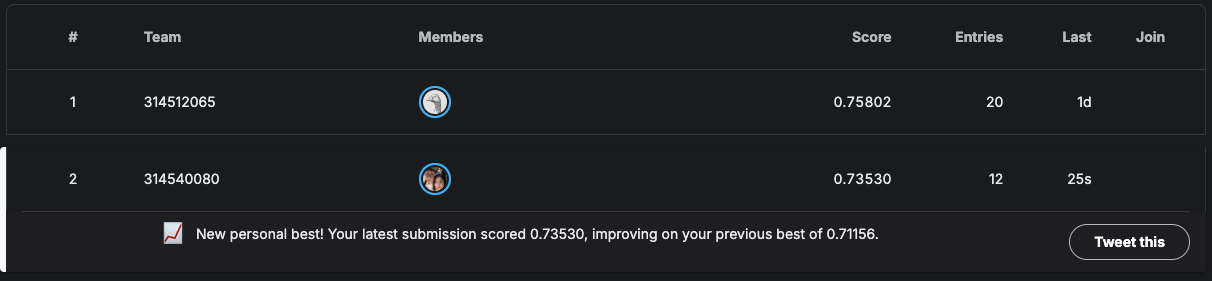